Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Starting the plant disease classification process using R-CNN...
Extracting dataset...
Extraction complete!
Loading data...
Found 32572 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Found 10885 images belonging to 38 classes.

Total training samples: 32572
Total validation samples: 10849
Total test samples: 10885
Steps per epoch: 1018
Number of classes: 38
Creating R-CNN model...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Starting training...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 201s 183ms/step - accuracy: 0.5289 - loss: 1.6611 - val_accuracy: 0.6618 - val_loss: 1.0861 - learning_rate: 0.0010
Epoch 2/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 175s 168ms/step - accuracy: 0.7262 - loss: 0.8494 - val_accuracy: 0.7874 - val_loss: 0.6323 - learning_rate: 0.0010
Epoch 3/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 172s 169ms/step - accuracy: 0.7761 - loss: 0.6932 - val_accuracy: 0.8323 - val_loss: 0.4761 - learning_rate: 0.0010
Epoch 4/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 183s 179ms/step - accuracy: 0.7959 - loss: 0.6322 - val_accuracy: 0.8274 - val_loss: 0.5416 - learning_rate: 0.0010
Epoch 5/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 173s 169ms/step - accuracy: 0.8128 - loss: 0.5810 - val_accuracy: 0.8667 - val_loss: 0.4083 - learning_rate: 0.0010
Epoch 6/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 200s 167ms/step - accuracy: 0.8224 - loss: 0.5463 - val_accuracy: 0.8644 - val_loss: 0.3956 - learning_rate: 0.0010
Epoch 7/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 171s 168ms

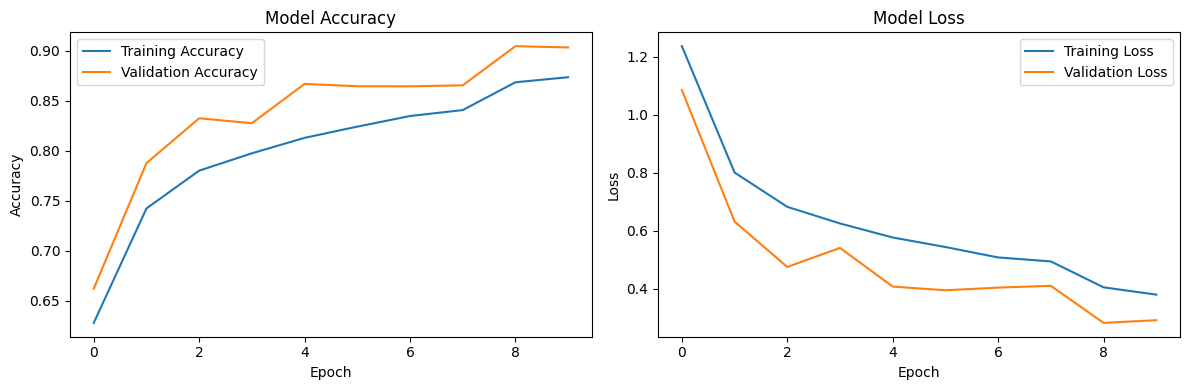

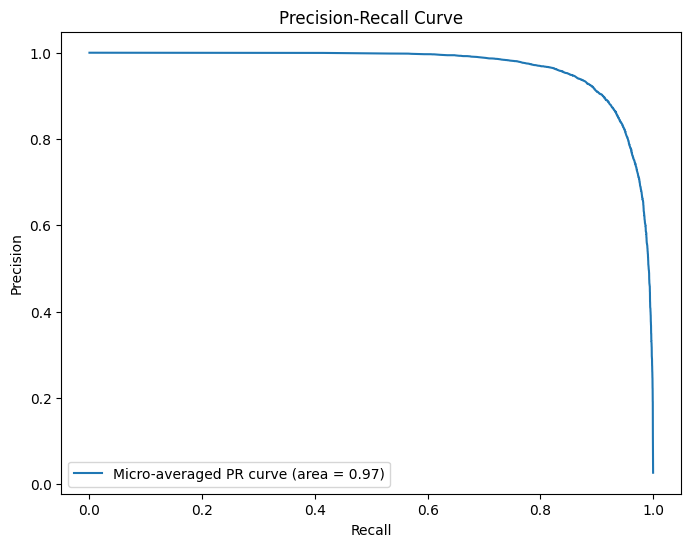


Final Accuracies:
Training Accuracy: 0.8734
Validation Accuracy: 0.9032
Testing Accuracy: 0.9032


In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Dropout, Dense, GlobalAveragePooling2D,
    BatchNormalization, Activation, Flatten, TimeDistributed, LSTM
)
from tensorflow.keras.applications import VGG16
import matplotlib.pyplot as plt
from google.colab import drive
import zipfile
from sklearn.metrics import precision_recall_curve, auc

# Enable mixed precision training
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Mount Google Drive
drive.mount('/content/drive')

def extract_dataset():
    zip_path = "/content/drive/MyDrive/Copy of PLANT_VILLAGE_SPLIT.zip"
    extract_path = "/content/plant_village"

    if not os.path.exists(extract_path):
        print("Extracting dataset...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("Extraction complete!")
    else:
        print("Dataset already extracted!")
    return extract_path

def create_rcnn(input_size=(128, 128, 3), num_classes=38):
    # Base CNN (VGG16)
    base_model = VGG16(
        include_top=False,
        weights='imagenet',
        input_shape=input_size
    )

    # Freeze the base model layers
    for layer in base_model.layers:
        layer.trainable = False

    # Create R-CNN model
    input_tensor = Input(shape=input_size)

    # CNN feature extraction
    x = base_model(input_tensor)

    # Additional convolutional layers for region proposal
    x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    # Region proposal network
    rpn = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    rpn = BatchNormalization()(rpn)

    # Classification head
    x = GlobalAveragePooling2D()(rpn)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_tensor, outputs=outputs)
    return model

def load_data(base_path, img_size=(128, 128)):
    data_generator = ImageDataGenerator(
        rescale=1./255,
        horizontal_flip=True,
        rotation_range=20,
        zoom_range=0.15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.15,
        fill_mode="nearest"
    )

    # Setup data generators
    train_generator = data_generator.flow_from_directory(
        os.path.join(base_path, 'PLANT_VILLAGE_SPLIT', 'train'),
        target_size=img_size,
        batch_size=32,
        class_mode='categorical',
        shuffle=True
    )

    # No augmentation for validation and test
    val_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
        os.path.join(base_path, 'PLANT_VILLAGE_SPLIT', 'val'),
        target_size=img_size,
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
        os.path.join(base_path, 'PLANT_VILLAGE_SPLIT', 'test'),
        target_size=img_size,
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    print(f"\nTotal training samples: {train_generator.n}")
    print(f"Total validation samples: {val_generator.n}")
    print(f"Total test samples: {test_generator.n}")
    print(f"Steps per epoch: {len(train_generator)}")

    return train_generator, val_generator, test_generator

def train_and_evaluate():
    # Extract dataset
    base_path = extract_dataset()

    # Load data
    print("Loading data...")
    train_generator, val_generator, test_generator = load_data(base_path)
    num_classes = len(train_generator.class_indices)
    print(f"Number of classes: {num_classes}")

    # Create and compile model
    print("Creating R-CNN model...")
    model = create_rcnn(input_size=(128, 128, 3), num_classes=num_classes)

    # Fixed learning rate configuration
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Add callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2
        )
    ]

    # Train model
    print("Starting training...")
    history = model.fit(
        train_generator,
        epochs=10,
        validation_data=val_generator,
        callbacks=callbacks,
        verbose=1
    )

    # Evaluate on test set
    print("Evaluating on test set...")
    test_loss, test_accuracy = model.evaluate(test_generator)
    print(f"Test accuracy: {test_accuracy:.4f}")

    # Get predictions for PR curve
    y_pred = model.predict(test_generator)
    y_test = test_generator.labels
    y_test = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)

    # Plot training history
    plt.figure(figsize=(12, 4))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Plot PR curve
    plt.figure(figsize=(8, 6))
    precision = dict()
    recall = dict()

    for i in range(num_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_test[:, i], y_pred[:, i])

    precision["micro"], recall["micro"], _ = precision_recall_curve(y_test.ravel(), y_pred.ravel())

    plt.plot(recall["micro"], precision["micro"], label=f'Micro-averaged PR curve (area = {auc(recall["micro"], precision["micro"]):.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.show()

    return (history.history['accuracy'][-1],
            history.history['val_accuracy'][-1],
            test_accuracy)

if __name__ == "__main__":
    print("Starting the plant disease classification process using R-CNN...")
    train_acc, val_acc, test_acc = train_and_evaluate()
    print(f"\nFinal Accuracies:")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")